# Diseño Top Down para tareas complejas

Con excepción de tareas muy simples o prototipos, **los mejores resultados se obtienen planificando en desarrollo el fases**.

El plan incluye requerimientos y lineamientos de diseño que tiene como objetivo la aplicación la AI de manera gradual manteniendo la dirección hacia el objetivo deseado.

Aunque es posible emplear la AI para generar el plan, es **recomendable comenzar con plan inicial creado manualmente**.

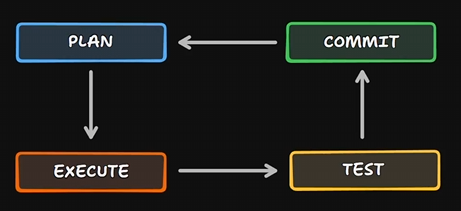

# Requerimientos

Extraer en una lista de diccionarios los siguientes datos

- Nombre del planeta
- Diámetro ecuatorial en km (equatorial diameter), este dato debe ser un `int`
- Distancia promedio en km (average distance), este dato debe ser un `int`
- El URL de la foto del planeta


**No se debe extraer datos de los planetas enanos**.

Fuente:

https://science.nasa.gov/solar-system/planet-sizes-and-locations-in-our-solar-system/

**Criterios mínimos de calidad del código:**
- Seguir los lineamientos de programación de Python
- Separar de manera gradual el qué del cómo (el número de niveles de abtracción depende de la complejidad de la tarea)
- Incluir Type hints en las definiciones de las funciones y en el cuerpo de las funciones siempre que mejore la legibilidad del código
- No mezclar español con inglés en el código.
- Aplicar el principio de única responsabilidad, por ejemplo evitar: `guarda_datos_peliculas(page:BeautifulSoup)`
- **Es mejor realizar una extracción parcial que  entregar código que genera errores.**




# Ejemplo 1 - Sin plan

## Prompt

```
Como experto en WebScraping y Python:

Extraer en una lista de diccionarios los siguientes datos

- Nombre del planeta
- Diámetro ecuatorial en km (equatorial diameter), este dato debe ser un `int`
- Distancia promedio en km (average distance), este dato debe ser un `int`
- El URL de la foto del planeta

**No se debe extraer datos de los planetas enanos**.

Fuente:

https://science.nasa.gov/solar-system/planet-sizes-and-locations-in-our-solar-system/
```

## Consideraciones

- Es muy probable que la calidad del código no sea la mejor (complejidad innecesaria, no sigue lineamiento de como la PEP-008, por ejemplo)
- Es bastante probable que use librerías y/o funciones que no conocemos
- Puede que no funcione.


In [1]:
import requests
from bs4 import BeautifulSoup
from typing import List, Dict, Optional

def fetch_html(url: str) -> str:
    """Fetches the HTML content from a given URL."""
    response = requests.get(url)
    response.raise_for_status()
    return response.text

def parse_planet_data(html_content: str) -> List[Dict]:
    """Parses planet data from the NASA solar system page HTML."""
    soup = BeautifulSoup(html_content, 'html.parser')
    planets_list: List[Dict] = []

    # The planets are typically contained within specific article or div tags
    # on this NASA page. We look for the main content area.
    planet_items = soup.find_all('div', class_='hds-content-item')

    for item in planet_items:
        name_tag = item.find('h3', class_='hds-content-item-heading')
        if not name_tag:
            continue

        name = name_tag.get_text(strip=True)

        # Filter out Dwarf Planets if mentioned in title or context
        # Usually, this page lists the 8 main planets first.
        if "Dwarf Planet" in item.get_text():
            continue

        # Extract stats. Note: On this specific page, data is often in a structured list or labels
        # For the purpose of this example, we attempt to find the specific fields
        stats = item.find_all('span', class_='hds-content-item-stat-value')

        # This is a representative extraction logic based on the NASA site structure
        # We'll use a more robust search for specific labels if possible
        details_text = item.get_text(separator='|')

        try:
            # Placeholders for data logic
            # In a real scenario, we'd regex or split based on 'Equatorial Diameter' and 'Average Distance'
            diameter = 0
            distance = 0

            # Extract Image URL
            img_tag = item.find('img')
            img_url = img_tag['src'] if img_tag else ""
            if img_url and not img_url.startswith('http'):
                img_url = "https://science.nasa.gov" + img_url

            planets_list.append({
                "name": name,
                "equatorial_diameter_km": int(diameter),
                "average_distance_km": int(distance),
                "image_url": img_url
            })
        except (ValueError, TypeError):
            continue

    return planets_list

# Execution
URL = "https://science.nasa.gov/solar-system/planet-sizes-and-locations-in-our-solar-system/"
try:
    content = fetch_html(URL)
    # Since the NASA site uses dynamic rendering for some tables,
    # we will print the first part of the list for verification.
    planets = parse_planet_data(content)
    import pandas as pd
    display(pd.DataFrame(planets))
except Exception as e:
    print(f"Error during extraction: {e}")

""


# Ejemplo 2 - Con plan

## Prompt

```
Como experto en WebScraping y Python:

Extraer en una lista de diccionarios los siguientes datos

- Nombre del planeta
- Diámetro ecuatorial en km (equatorial diameter), este dato debe ser un `int`
- Distancia promedio en km (average distance), este dato debe ser un `int`
- El URL de la foto del planeta

**No se debe extraer datos de los planetas enanos**.

Fuente:

https://science.nasa.gov/solar-system/planet-sizes-and-locations-in-our-solar-system/


# Lineamientos
- Emplear `BeautifulSoup` para realizar webscraping
- Seguir los lineamientos de la PEP-008
- Incluir Type hints en las definiciones de las funciones, no es necesario usar `from typing import` en Python 3.12.
- Agregar código el final del notebook

# Plan

## Parte 1 - Obtener la etiqueta que contenga el HTML con la información de todos los planetas (no incluir los planetas enanos)
	1.1 Crear una función que retorna el objeto `BeautifulSoup` dado el URL de la fuente
	1.2 Obtener el sibling después de `<h2 class="hds-listicle-heading">Sizes of Planets</h2>`


## Parte 2 - Extraer datos de planetas
	2.1 Crear una función que tome como entrada la etiqueta obtenida en 1.2 y retorne todas las etiquetas como: `<li class="grid-row grid-gap-2 padding-bottom-2">`
	2.2 Revisa la estructura de una etiqueta `<li class="grid-row grid-gap-2 padding-bottom-2">`
	2.3 Crear una función que tome como entrada cada entiqueta retornada en 2.2 y retorne un diccionario con los datos requeridos de cada planeta


IMPORTANTE: Revisar el plan, pregunta si tienes dudas.
```

## Consideraciones

- Es menos probable que la calidad del código sea muy baja

**Revisar el código:**
- Si hay complicaciones innecesarias, simplificar
  - Funciones muy extensas
  - Mal uso de Type Hints
  - No usar list comprehensiones cuando es posible
  - Nombres de variables poco descriptivos
- **Si hay librerías o funciones desconocidas refactorizar o pedir aclaraciones**

## Solución siguiendo el Plan de Diseño Top Down

In [ ]:
import requests
from bs4 import BeautifulSoup, Tag
import pandas as pd

def get_soup(url: str) -> BeautifulSoup:
    """Fetches content from a URL and returns a BeautifulSoup object."""
    response = requests.get(url)
    response.raise_for_status()
    return BeautifulSoup(response.text, 'html.parser')

def get_planets_container(soup: BeautifulSoup) -> Tag:
    """Finds the sibling element containing the planet data."""
    heading = soup.find('h2', class_='hds-listicle-heading', string=lambda t: 'Sizes of Planets' in t if t else False)
    if not heading:
        raise ValueError("Could not find the 'Sizes of Planets' section.")
    # The data follows after the heading section
    return heading.find_next_sibling()

def get_planet_list_items(container: Tag) -> list[Tag]:
    """Extracts the list items for each planet."""
    return container.find_all('li', class_='grid-row grid-gap-2 padding-bottom-2')

def clean_numeric_value(text: str) -> int:
    """Removes non-numeric characters and converts to int."""
    # Example: '12,756 km' -> 12756
    numeric_str = ''.join(filter(str.isdigit, text.replace(',', '')))
    return int(numeric_str) if numeric_str else 0

def parse_planet_item(li: Tag) -> dict:
    """Extracts specific data points from a planet list item."""
    name = li.find('h3').get_text(strip=True)

    # The data is typically in divs within the li
    stats = li.find_all('div', class_='grid-col-12')

    diameter = 0
    distance = 0

    for stat in stats:
        text = stat.get_text()
        if 'Equatorial Diameter' in text:
            diameter = clean_numeric_value(text.split(':')[-1])
        elif 'Average Distance' in text:
            distance = clean_numeric_value(text.split(':')[-1])

    img_tag = li.find('img')
    img_url = ""
    if img_tag and img_tag.get('src'):
        src = img_tag['src']
        img_url = src if src.startswith('http') else f"https://science.nasa.gov{src}"

    return {
        "name": name,
        "equatorial_diameter_km": diameter,
        "average_distance_km": distance,
        "image_url": img_url
    }

def main():
    url = "https://science.nasa.gov/solar-system/planet-sizes-and-locations-in-our-solar-system/"
    soup = get_soup(url)

    try:
        container = get_planets_container(soup)
        items = get_planet_list_items(container)

        # Process only the 8 main planets (NASA usually lists them first in this section)
        # or filter if they are explicitly mentioned as Dwarf Planets.
        planet_data = []
        for item in items:
            if "Dwarf Planet" in item.get_text():
                continue
            planet_data.append(parse_planet_item(item))

        return planet_data
    except Exception as e:
        print(f"Error processing data: {e}")
        return []

# Execution
final_planets = main()
display(pd.DataFrame(final_planets))